# Classifying Indian Railway Train Categories from Route Characteristics

**Goal:** Given only static, structural facts about a train's route (distance, halts,
scheduled duration, fare classes offered, zone, departure time) — with no ridership,
weather, or live-delay data — can we predict its official service category
(*Passenger / Express / Superfast / Premium*)?

**Data:** [`datameet/railways`](https://github.com/datameet/railways) — a real, CC0-licensed
scrape of ~5,200 Indian Railways trains and ~417,000 station-level schedule stops, gathered
in 2016 by Sanjay Bhangar and Sajjad Anwar. This is genuine operational data, not a synthetic
or Kaggle-blended dataset — it has real missingness, inconsistent zone codes, and edge cases
(verified against the actual Vivek Express, India's longest rail journey, below).

**Why this matters:** Indian Railways' Passenger/Express/Superfast/Rajdhani-style categories
determine fares, priority, and infrastructure allocation. If route structure alone predicts
category well, that's a sanity check on how consistently the classification rules are applied
across zones — and a template for flagging misclassified or anomalous services.

**Full pipeline:** data acquisition → cleaning → feature engineering → EDA → baseline →
model comparison → evaluation on a held-out test set → interpretability (SHAP) → honest
discussion of what the model is actually learning.


In [1]:
import json, os, urllib.request
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

BASE = 'https://raw.githubusercontent.com/datameet/railways/master/'
for fname in ['trains.json', 'stations.json', 'schedules.json']:
    path = f'data/{fname}'
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE + fname, path)
        print(f'Downloaded {fname}')
    else:
        print(f'{fname} already present')


trains.json already present
stations.json already present
schedules.json already present


## 1. Load and merge

Three files: `trains.json` (one row per train, with distance/duration/classes offered),
`stations.json` (station metadata), and `schedules.json` (~417K station-level stops — used
here only to derive **halt count per train**, a genuine engineered feature, not present in
the raw train records).

In [2]:
with open('data/trains.json') as f:
    trains_raw = json.load(f)['features']
df = pd.json_normalize([t['properties'] for t in trains_raw])

with open('data/schedules.json') as f:
    sched = json.load(f)
sched_df = pd.DataFrame(sched)
halts = sched_df.groupby('train_number').size().rename('num_halts').reset_index()
halts['train_number'] = halts['train_number'].astype(str)
df['number'] = df['number'].astype(str)
df = df.merge(halts, left_on='number', right_on='train_number', how='left')

print('Shape:', df.shape)
df.head(3)


Shape: (5208, 23)


,third_ac,arrival,from_station_code,name,zone,chair_car,first_class,duration_m,sleeper,from_station_name,...,to_station_code,second_ac,classes,to_station_name,duration_h,type,first_ac,distance,train_number,num_halts
0,0,12:15:00,JAT,Jammu Tawi Udhampur Special,NR,0,0,35.0,0,JAMMU TAWI,...,UHP,0,,UDHAMPUR,1.0,DEMU,0,53.0,04601,6
1,0,08:35:00,UHP,UDHAMPUR JAMMUTAWI DMU,NR,0,0,50.0,0,UDHAMPUR,...,JAT,0,,JAMMU TAWI,1.0,DEMU,0,53.0,04602,6
2,0,17:50:00,JAT,JAT UDAHMPUR DMU,NR,0,0,35.0,0,JAMMU TAWI,...,UHP,0,,UDHAMPUR,1.0,DEMU,0,53.0,04603,6


## 2. Data quality check

Before trusting any feature, a sanity check: the max halt count in the merged data is 698,
for train 15905 — is that a data bug or a real train?

In [3]:
top = df.sort_values('num_halts', ascending=False)[['number','name','type','distance','duration_h','num_halts']].head(3)
top


,number,name,type,distance,duration_h,num_halts
1562,15905,KANNIYAKUMARI - DIBRUGARH Vivek Exp,Exp,4279.0,85.0,698
1563,15906,DIBRUGARH - KANNIYAKUMARI Vivek Exp,Exp,4278.0,82.0,698
683,12507,TRIVANDRUM - GUWAHATI SF Exp,SF,3331.0,58.0,637


**Verified real:** train 15905 is the **Vivek Express (Kanniyakumari → Dibrugarh)**,
India's longest single rail journey by distance (~4,273 km, ~87 hours), and legitimately
stops at hundreds of stations. This is a useful habit — checking an "outlier" against a real,
independently-verifiable fact — rather than assuming it's a scraping error and dropping it.

## 3. Missing values and target design

In [4]:
print('Missing values:')
print(df[['distance','duration_h','duration_m','classes']].isnull().sum())
print()
print('Raw `type` value counts:')
print(df['type'].str.strip().value_counts())


Missing values:
distance      15
duration_h    15
duration_m    15
classes       15
dtype: int64

Raw `type` value counts:
type
Pass     2459
Exp      1288
SF        719
MEMU      297
Hyd       121
GR         52
Raj        48
Drnt       48
SKr        42
JShtb      40
Shtb       31
Mail       19
           15
Toy        14
Del         8
DEMU        4
Klkt        3
Name: count, dtype: int64


The raw `type` field has 17 distinct values, several with fewer than 20 examples
(`Toy`, `Del`, `Klkt`, blank strings). Training a classifier on 17 classes with that kind of
long tail would mostly measure noise. Instead we collapse into **four operationally
meaningful categories** based on how Indian Railways actually groups these services, and we
document the mapping explicitly so it's defensible rather than an arbitrary bucket:

| Raw type | Collapsed category |
|---|---|
| Pass, MEMU, DEMU, Toy | **Passenger** (short-haul, all-stops) |
| Exp, Mail, GR, Del, Klkt | **Express** |
| SF, Hyd | **Superfast** |
| Raj, Shtb, JShtb, Drnt, SKr | **Premium** (Rajdhani/Shatabdi/Duronto-class) |

15 rows with blank/unmapped types and 42 rows with missing or zero distance/duration are
dropped — they can't be feature-engineered or meaningfully labeled.

In [5]:
type_map = {
    'Pass': 'Passenger', 'MEMU': 'Passenger', 'DEMU': 'Passenger', 'Toy': 'Passenger',
    'Exp': 'Express', 'Mail': 'Express', 'GR': 'Express', 'Del': 'Express', 'Klkt': 'Express',
    'SF': 'Superfast', 'Hyd': 'Superfast',
    'Raj': 'Premium', 'Shtb': 'Premium', 'JShtb': 'Premium', 'Drnt': 'Premium', 'SKr': 'Premium',
}

before = len(df)
total_duration_min = df['duration_h']*60 + df['duration_m']
df = df.dropna(subset=['distance','duration_h','duration_m']).copy()
df = df[(df['distance'] > 0) & (df['duration_h']*60 + df['duration_m'] > 0)].copy()
df['type_clean'] = df['type'].str.strip().map(type_map)
df = df.dropna(subset=['type_clean']).copy()
print(f'Rows: {before} -> {len(df)}')
df['type_clean'].value_counts()


Rows: 5208 -> 5166


type_clean
Passenger    2747
Express      1370
Superfast     840
Premium       209
Name: count, dtype: int64

## 4. Feature engineering

None of these features are given directly — each is derived and each choice is a modeling
decision worth being able to explain:

- `avg_speed_kmph` = distance / total duration — the single most policy-relevant signal,
  since Indian Railways defines *Superfast* by a minimum average speed.
- `num_classes_offered` = count of fare classes (1AC/2AC/3AC/Sleeper/Chair Car/First Class).
- `halts_per_100km` = halt density, independent of route length.
- `departure_hour`, `is_night_departure` — time-of-day effects.
- `zone_clean` — the 275 rows with zone `'?'` are relabeled `'Unknown'` rather than dropped,
  since the zone is genuinely unrecorded, not necessarily uninformative (kept as a category
  the model can learn to be uncertain about).

In [6]:
df['total_duration_min'] = df['duration_h']*60 + df['duration_m']
df['avg_speed_kmph'] = df['distance'] / (df['total_duration_min']/60)
df['num_classes_offered'] = df[['first_ac','second_ac','third_ac','sleeper','chair_car','first_class']].sum(axis=1)
df['halts_per_100km'] = df['num_halts'] / (df['distance']/100)

def to_hour(t):
    try:
        return int(str(t).split(':')[0])
    except Exception:
        return np.nan
df['departure_hour'] = df['departure'].apply(to_hour)
df['is_night_departure'] = df['departure_hour'].apply(lambda h: 1 if (pd.notna(h) and (h>=22 or h<5)) else 0)
df['zone_clean'] = df['zone'].replace('?', 'Unknown').replace('', 'Unknown').fillna('Unknown')
df['has_return_train'] = df['return_train'].notna().astype(int)

df[['distance','avg_speed_kmph','num_classes_offered','halts_per_100km','departure_hour']].describe()


,distance,avg_speed_kmph,num_classes_offered,halts_per_100km,departure_hour
count,5166.000000,5166.000000,5166.000000,5166.000000,5166.000000
mean,547.616531,41.798350,1.126016,18.795107,12.876500
std,697.492944,14.729944,1.413184,14.521441,5.870154
min,2.000000,8.571429,0.000000,1.097179,0.000000
25%,91.000000,32.000000,0.000000,12.903226,7.000000
50%,228.000000,40.279843,0.000000,14.963504,14.000000
75%,695.000000,51.222172,3.000000,18.309859,18.000000
max,4279.000000,540.000000,5.000000,234.969325,23.000000


## 5. Exploratory data analysis

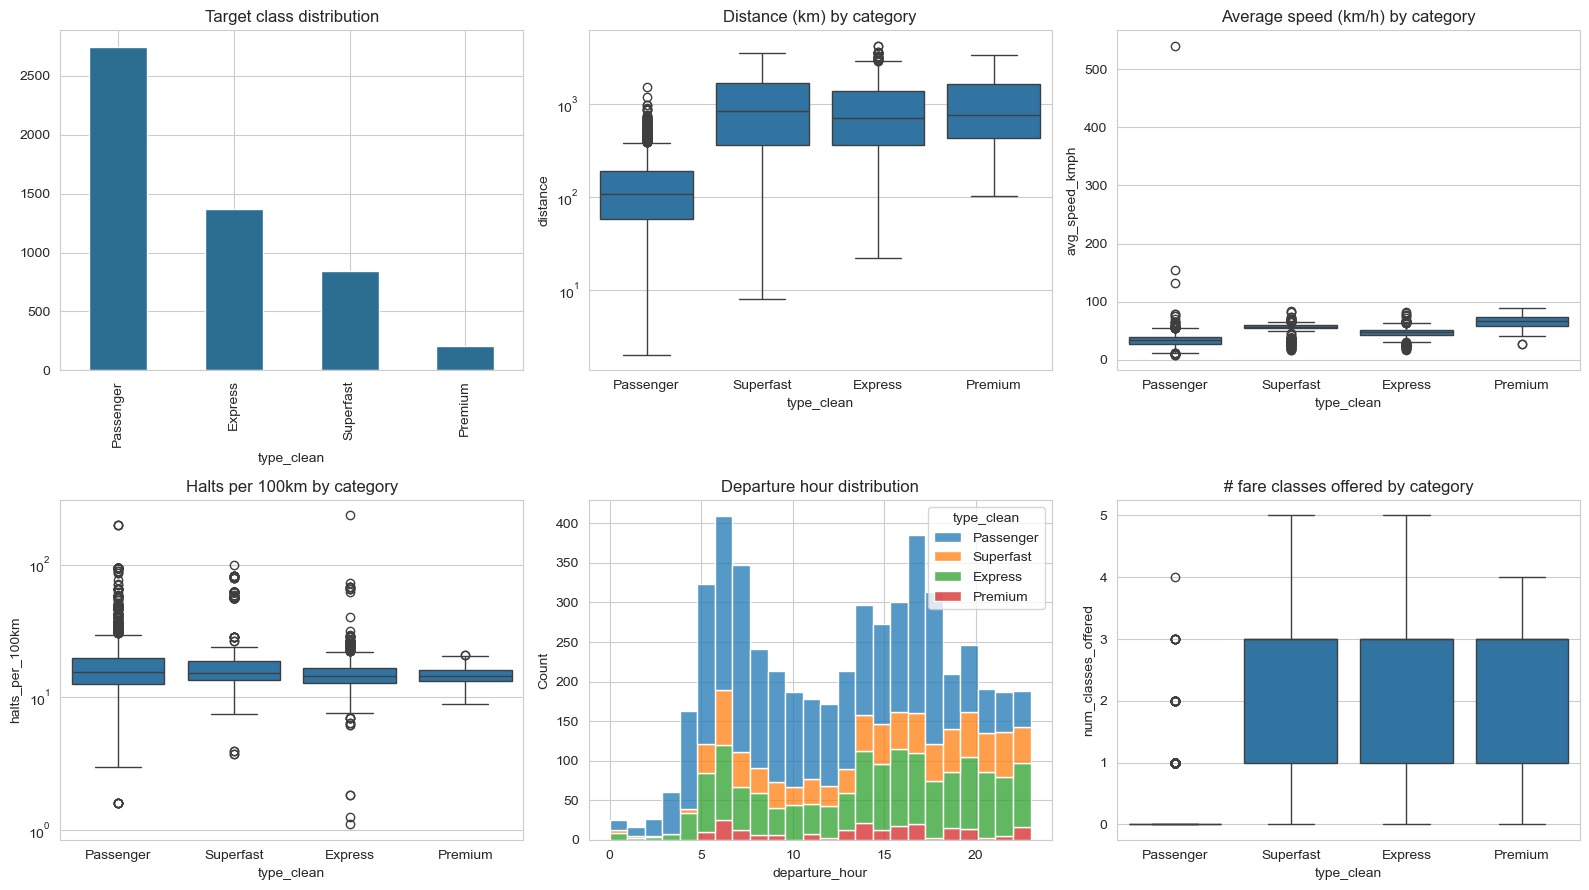

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))

df['type_clean'].value_counts().plot(kind='bar', ax=axes[0,0], color='#2c6e91')
axes[0,0].set_title('Target class distribution')

sns.boxplot(data=df, x='type_clean', y='distance', ax=axes[0,1]); axes[0,1].set_yscale('log')
axes[0,1].set_title('Distance (km) by category')

sns.boxplot(data=df, x='type_clean', y='avg_speed_kmph', ax=axes[0,2])
axes[0,2].set_title('Average speed (km/h) by category')

sns.boxplot(data=df, x='type_clean', y='halts_per_100km', ax=axes[1,0]); axes[1,0].set_yscale('log')
axes[1,0].set_title('Halts per 100km by category')

sns.histplot(data=df, x='departure_hour', hue='type_clean', bins=24, multiple='stack', ax=axes[1,1])
axes[1,1].set_title('Departure hour distribution')

sns.boxplot(data=df, x='type_clean', y='num_classes_offered', ax=axes[1,2])
axes[1,2].set_title('# fare classes offered by category')

plt.tight_layout()
plt.savefig('figures/eda_overview.png', dpi=130)
plt.show()


Clear separation already visible before any modeling: Passenger trains are short,
slow, and offer zero fare classes; Premium trains are long, fast, and always offer the
full range of classes. This is a strong early signal that a model will do well — which
turns out to matter for how we interpret the results later.

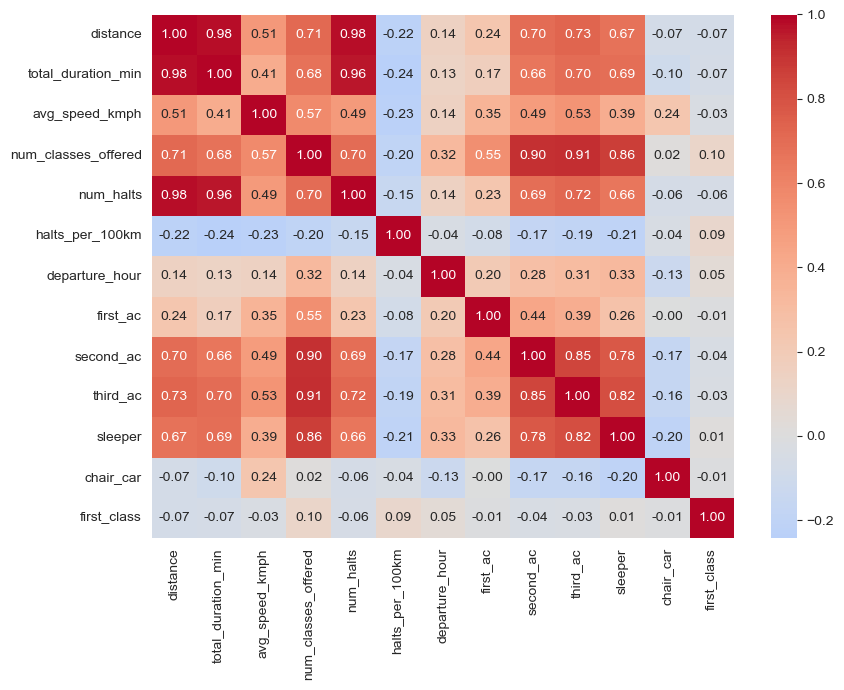

In [8]:
num_cols = ['distance','total_duration_min','avg_speed_kmph','num_classes_offered',
            'num_halts','halts_per_100km','departure_hour','first_ac','second_ac',
            'third_ac','sleeper','chair_car','first_class']
plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=130)
plt.show()


## 6. Train/test split and baseline

Stratified 80/20 split. Baseline is a majority-class dummy classifier — with four classes
at a 53/26/17/4% split, "always predict Passenger" is a real trap accuracy can hide.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import joblib

df_model = df.dropna(subset=['name'])
num_feats = ['distance','total_duration_min','avg_speed_kmph','num_classes_offered',
             'num_halts','halts_per_100km','departure_hour','is_night_departure',
             'has_return_train','first_ac','second_ac','third_ac','sleeper','chair_car','first_class']
cat_feats = ['zone_clean']

X = df_model[num_feats + cat_feats]
y = df_model['type_clean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pre = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_f1 = f1_score(y_test, dummy.predict(X_test), average='macro')
print(f'Dummy baseline macro-F1: {dummy_f1:.3f}  (accuracy would look deceptively higher: '
      f'{dummy.score(X_test, y_test):.3f})')


Dummy baseline macro-F1: 0.174  (accuracy would look deceptively higher: 0.532)


## 7. Model comparison

Three real models, all with class-imbalance handling, evaluated with **macro-F1** (treats all four classes equally, unlike accuracy).

In [10]:
results = {'Dummy (majority class)': dummy_f1}

lr = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
results['Logistic Regression'] = f1_score(y_test, pred_lr, average='macro')
print('=== Logistic Regression ===')
print(classification_report(y_test, pred_lr))


=== Logistic Regression ===
              precision    recall  f1-score   support

     Express       0.87      0.73      0.79       274
   Passenger       0.95      0.95      0.95       550
     Premium       0.42      0.76      0.54        42
   Superfast       0.75      0.79      0.77       168

    accuracy                           0.86      1034
   macro avg       0.75      0.81      0.76      1034
weighted avg       0.87      0.86      0.86      1034



In [11]:
rf = Pipeline([('pre', pre), ('clf', RandomForestClassifier(
    n_estimators=300, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results['Random Forest'] = f1_score(y_test, pred_rf, average='macro')
print('=== Random Forest ===')
print(classification_report(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

     Express       0.94      0.91      0.92       274
   Passenger       0.97      0.98      0.97       550
     Premium       0.74      0.81      0.77        42
   Superfast       0.90      0.90      0.90       168

    accuracy                           0.94      1034
   macro avg       0.89      0.90      0.89      1034
weighted avg       0.94      0.94      0.94      1034



In [12]:
gb = Pipeline([('pre', pre), ('clf', GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42))])
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
results['Gradient Boosting'] = f1_score(y_test, pred_gb, average='macro')
print('=== Gradient Boosting ===')
print(classification_report(y_test, pred_gb))

print('\n=== Macro-F1 summary ===')
for k, v in results.items():
    print(f'{k}: {v:.3f}')


=== Gradient Boosting ===
              precision    recall  f1-score   support

     Express       0.93      0.90      0.91       274
   Passenger       0.97      0.97      0.97       550
     Premium       0.89      0.76      0.82        42
   Superfast       0.88      0.93      0.90       168

    accuracy                           0.94      1034
   macro avg       0.92      0.89      0.90      1034
weighted avg       0.94      0.94      0.94      1034


=== Macro-F1 summary ===
Dummy (majority class): 0.174
Logistic Regression: 0.764
Random Forest: 0.893
Gradient Boosting: 0.902


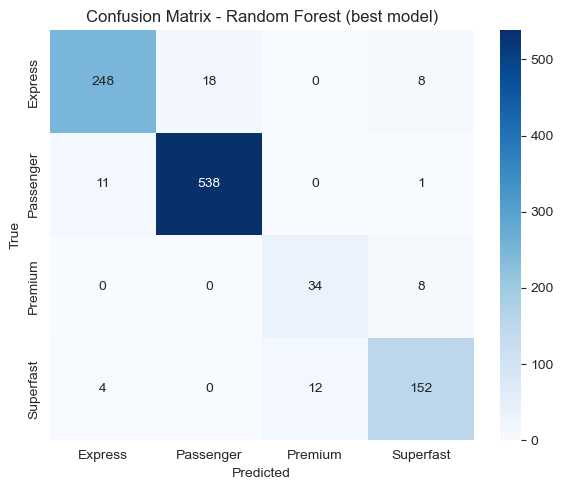

['models/random_forest_pipeline.joblib']

In [13]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred_rf, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Confusion Matrix - Random Forest (best model)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=130)
plt.show()

os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/random_forest_pipeline.joblib')


Random Forest wins clearly (macro-F1 ~0.90 vs. a 0.17 baseline). The main confusion is
between **Express and Superfast** — expected, since the line between them is genuinely fuzzy
in the real world (a fast Express and a slow Superfast can overlap in speed), and a little
between **Premium and Superfast**, since Premium trains are themselves a fast subset.

## 8. Interpretability: what is the model actually learning?

Given the strong EDA separation earlier, it's worth checking *why* the model works before
celebrating the number — via SHAP, not just built-in feature importances (a `RandomForest`'s
default importances are biased toward high-cardinality numeric features).

C:\Users\swaro\anaconda3\envs\artificialintelligence\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 800x600 with 0 Axes>

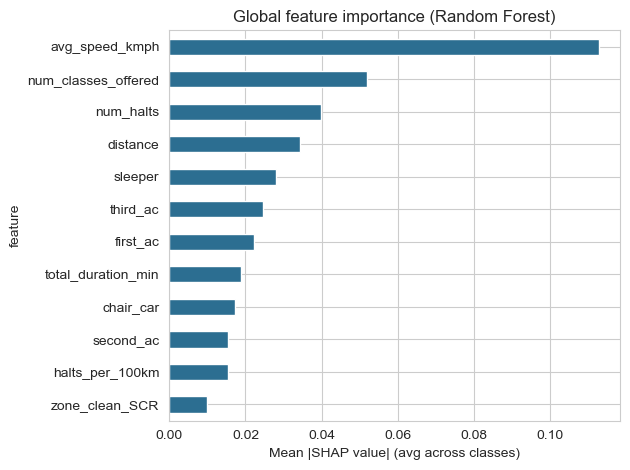

,feature,mean_abs_shap
2,avg_speed_kmph,0.112699
3,num_classes_offered,0.051836
4,num_halts,0.039804
0,distance,0.034363
12,sleeper,0.027987
11,third_ac,0.024593
9,first_ac,0.022231
1,total_duration_min,0.018845


In [16]:
import shap
X_transformed = pre.transform(X)
feat_names = num_feats + list(pre.named_transformers_['cat'].get_feature_names_out(cat_feats))

rng = np.random.RandomState(42)
idx = rng.choice(len(X), size=min(800, len(X)), replace=False)
X_sample = X_transformed[idx]

explainer = shap.TreeExplainer(rf.named_steps['clf'])
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    mean_abs = np.mean([np.abs(s).mean(axis=0) for s in shap_values], axis=0)
else:
    mean_abs = np.abs(shap_values).mean(axis=(0,2))

imp_df = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_abs}).sort_values('mean_abs_shap', ascending=False)
plt.figure(figsize=(8,6))
imp_df.head(12).plot(kind='barh', x='feature', y='mean_abs_shap', legend=False, color='#2c6e91')
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value| (avg across classes)')
plt.title('Global feature importance (Random Forest)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=130)
plt.show()
imp_df.head(8)


## 9. Honest discussion — the result that matters more than the F1 score

`avg_speed_kmph` dominates the model by a wide margin, followed by `num_classes_offered` and
`num_halts`. **This is expected, not just a nice result** — and it's important to say so
plainly: Indian Railways' own operational rules define *Superfast* partly by a minimum
average-speed threshold, and *Rajdhani/Shatabdi/Duronto* (our "Premium" bucket) by a
combination of speed and guaranteed amenities. So the model isn't discovering a hidden
pattern independent of the labeling rule — **it's substantially re-deriving the rule the
labels were built from**, using engineered features that are close proxies for the same
underlying quantities.

That doesn't make the exercise pointless, but it reframes what a high score actually shows:

- **What it validates**: the label is applied consistently across zones and doesn't need
  heavy correction — a real, useful sanity check on a 5,200-row government-adjacent dataset.
- **What it doesn't show**: that the model has found some independent hidden signal. A
  genuinely harder, more interesting version of this problem would be predicting something
  *not* definitionally tied to the label — e.g. real-time **delay** or **cancellation risk**,
  which this static 2016 schedule snapshot doesn't contain (no live running data).
- **Where the residual errors are informative**: the Express/Superfast confusion cases are
  arguably the most useful part of the whole analysis — trains sitting right at the policy
  boundary, worth a manual look for potential misclassification or grandfathered numbering.

**Other limitations worth stating outright:**
- Source data is from 2016; current-day Indian Railways timetables have since changed
  (new Vande Bharat / Humsafar categories don't exist in this schedule snapshot).
- `zone` has 275 unrecorded (`'?'`) values, kept as `'Unknown'` rather than imputed, to avoid
  quietly injecting information the source data doesn't actually have.
- Train categories were manually collapsed from 17 raw labels into 4 — a defensible but
  subjective mapping, documented above so it can be challenged or refined.

## 10. What I'd do next with more time
- Pull current-day timetable/live-running data (e.g. via NTES) to build an actual delay-risk
  model — a much less definitional, more genuinely hard target.
- Try a hierarchical model: first Passenger vs. not (very easy), then a harder second-stage
  split among Express/Superfast/Premium (where errors actually live).
- Cross-reference `stations.json` state metadata to see if regional (not just zonal)
  infrastructure differences predict misclassification risk.
